# Wan TI2V Causal Window and Recurrent Memory

This notebook uses the `new` conda environment/kernel. The shared local attention is causal and frame-blocked: query tokens in latent frame `f` attend to frames `[f-l, ..., f]` with temporal RoPE applied relative to that local window. The clean first latent frame is patchified separately, passed through a zero-init linear conditioner, and added to input patch tokens before the transformer blocks. `TRAINING_MODE="flow_matching"` keeps the LoRA flow-matching path; `TRAINING_MODE="ssm"` switches to a separate LoRA + frame-level diagonal state-space memory student; `TRAINING_MODE="delta_distill"` keeps the older delta-attention recurrent student for comparison. Both recurrent modes train with the same windowed flow-matching loss and error recycling. Training conditions on normalized `log(nu)` and `log(rho)`, filters the dataset by safetensor latent-frame count, and truncates to `LATENT_FRAME_COUNT` only inside the training batch path.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "navier":
    NOTEBOOK_DIR = Path("/home/azureuser/physics/navier")
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import autoreg_windowed_lora as awl

print(sys.executable)
print("device:", awl.DEVICE)

/opt/miniforge/envs/new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/opt/miniforge/envs/new/bin/python
device: cuda


In [2]:
import torch

CONFIG = dict(
    LATENT_ROOT=Path("/home/azureuser/datasets/navier_fast"),
    WAN_REPO_ROOT=Path("/home/azureuser/physics/navier/Wan2.2"),
    WAN_CHECKPOINT_DIR=Path("/home/azureuser/Wan2.2-TI2V-5B"),
    OUTPUT_DIR=Path("/home/azureuser/physics/navier/autoreg_lora_outputs"),
    TEXT_EMBED_CACHE_PATH=Path("/home/azureuser/physics/navier/wan_t5_prompt_embeddings.safetensors"),
    POSITIVE_PROMPT="aerodynamic flow around an object",
    NEGATIVE_PROMPT="bad quality",
    DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    PARAM_DTYPE=torch.bfloat16,
    TRAIN_DTYPE=torch.bfloat16,
    BATCH_SIZE=2,
    GRAD_ACCUM_STEPS=1,
    LEARNING_RATE=1e-4,
    LR_WARMUP_STEPS=1,
    MAX_STEPS=20000,
    CLIP_GRAD_NORM=1.0,
    LOSS_EMA_BETA=0.98,
    VELOCITY_L2_LOSS_WEIGHT=1.0,
    GRADIENT_CHECKPOINT_DISABLE_BLOCKS="all",
    TRAINING_MODE="ssm",  # "ssm" enables the separate LoRA + frame-level SSM path
    TRAIN_INIT_LOGS=True,
    REGIONAL_COMPILE=False,
    REGIONAL_COMPILE_BACKEND="inductor",
    REGIONAL_COMPILE_MODE="reduce-overhead",
    REGIONAL_COMPILE_FULLGRAPH=False,
    REGIONAL_COMPILE_DYNAMIC=False,
    REGIONAL_COMPILE_CAPTURE_SCALAR_OUTPUTS=True,
    USE_FLEX_ATTENTION=True,
    FLEX_ATTENTION_BLOCK_SIZE=64,
    FIRST_FRAME_CONDITIONING_DIM=64,
    ERROR_RECYCLING_WARMUP_STEPS=200,
    ERROR_RECYCLING_PROB=0.5,
    ERROR_RECYCLING_SCALE=1.0,
    ERROR_RECYCLING_TIMESTEP_BINS=50,
    ERROR_RECYCLING_BANK_SIZE=8,
    WINDOW_LEFT_FRAMES=4,
    WINDOW_RIGHT_FRAMES=0,
    MIN_LATENT_FRAME_COUNT=36,
    LATENT_FRAME_COUNT=18,
    HOLDOUT_COUNT=100,
    EVAL_EVERY=300,
    EVAL_INFERENCE_STEPS=20,
    EVAL_FPS=16,
    EVAL_ERROR_VMAX=0.45,
    VIDEO_OUTPUT_SIZE=256,
    SAVE_EVERY=None,
    LORA_R=64,
    LORA_ALPHA=64,
    LORA_DROPOUT=0.0,
    LORA_TARGET_MODULES=[
        "self_attn.q",
        "self_attn.k",
        # "self_attn.v",
        # "self_attn.o",
        # "ffn.0",
        # "ffn.2",
    ],
    DELTA_ATTENTION_BETA_INIT=1e-3,
    DELTA_ATTENTION_LAMBDA_INIT=0.999,
    DELTA_ATTENTION_RHO_INIT=0.0,
    DELTA_ATTENTION_FREEZE_RHO_ZERO=False,
    DELTA_ATTENTION_KEY_SCALE=None,
    SSM_DECAY_INIT=0.999,
    SSM_INPUT_INIT=1e-3,
    SSM_OUTPUT_INIT=1.0,
    SSM_SKIP_INIT=0.0,
    SSM_RHO_INIT=0.0,
    SSM_FREEZE_RHO_ZERO=False,
    SSM_QUERY_SCALE=None,
    SSM_RECURRENT_DIM=1024,
    WAN_NUM_TRAIN_TIMESTEPS=1000,
    WAN_SAMPLE_SHIFT=5.0,
    WAN_SAMPLE_GUIDE_SCALE=1.0,
    WAN_SAMPLE_SOLVER="unipc",
    REQUIRE_RHO=True,
    RANDOM_SEED=1234,
)

awl.configure(**CONFIG)
for key, value in awl.get_config().items():
    print(f"{key}: {value}")

LATENT_ROOT: /home/azureuser/datasets/navier_fast
WAN_REPO_ROOT: /home/azureuser/physics/navier/Wan2.2
WAN_CHECKPOINT_DIR: /home/azureuser/Wan2.2-TI2V-5B
OUTPUT_DIR: /home/azureuser/physics/navier/autoreg_lora_outputs
TEXT_EMBED_CACHE_PATH: /home/azureuser/physics/navier/wan_t5_prompt_embeddings.safetensors
POSITIVE_PROMPT: aerodynamic flow around an object
NEGATIVE_PROMPT: bad quality
DEVICE: cuda
PARAM_DTYPE: torch.bfloat16
TRAIN_DTYPE: torch.bfloat16
BATCH_SIZE: 2
GRAD_ACCUM_STEPS: 1
LEARNING_RATE: 0.0001
LR_WARMUP_STEPS: 1
MAX_STEPS: 20000
CLIP_GRAD_NORM: 1.0
LOSS_EMA_BETA: 0.98
VELOCITY_L2_LOSS_WEIGHT: 1.0
GRADIENT_CHECKPOINT_DISABLE_BLOCKS: all
TRAINING_MODE: ssm
TRAIN_INIT_LOGS: True
REGIONAL_COMPILE: False
REGIONAL_COMPILE_BACKEND: inductor
REGIONAL_COMPILE_MODE: reduce-overhead
REGIONAL_COMPILE_FULLGRAPH: False
REGIONAL_COMPILE_DYNAMIC: False
REGIONAL_COMPILE_CAPTURE_SCALAR_OUTPUTS: True
USE_FLEX_ATTENTION: True
FLEX_ATTENTION_BLOCK_SIZE: 64
FIRST_FRAME_CONDITIONING_DIM: 64
ER

In [3]:
import torch

grid = torch.tensor([[4, 2, 3]])
mask = awl.frame_window_mask(grid, seq_len=24, left_frames=1, right_frames=0)[0]
assert torch.where(mask[0])[0].tolist() == list(range(6))
assert torch.where(mask[12])[0].tolist() == list(range(6, 18))
assert torch.where(mask[18])[0].tolist() == list(range(12, 24))
print("mask ok: causal left window without first-frame anchor")


mask ok: causal left window without first-frame anchor


In [4]:
samples = awl.discover_latent_samples()
train_samples, holdout_samples = awl.make_splits(samples)
print(f"latents: {len(samples):,}")
print(f"train: {len(train_samples):,}")
print(f"holdout: {len(holdout_samples):,}")
print("example:", samples[0].latents_path)


[sample discovery] checking 2,001 latent files in /home/azureuser/datasets/navier_fast (min latent frames=36)
[sample discovery] checked 500/2,001; kept 500; elapsed 0.0s
[sample discovery] checked 1,000/2,001; kept 1,000; elapsed 0.1s


[sample discovery] checked 1,500/2,001; kept 1,500; elapsed 0.1s
[sample discovery] checked 2,000/2,001; kept 2,000; elapsed 0.2s
[sample discovery] done in 0.2s; kept 2,001; skipped_short=0; skipped_bad_latents=0; skipped_metadata=0
latents: 2,001
train: 1,901
holdout: 100
example: /home/azureuser/datasets/navier_fast/001990c0b059f626/latents.safetensors


ssm-window:  12%|█▏        | 2399/20000 [35:23<4:02:45,  1.21it/s, bank=400, latent_err=0.053634, noise_err=0.057569, replay=0.56, window_ema=0.139177]

step 2400: 58186e7f0d9c2bfd | nu=8.98e-04, rho=0.69 | left=ssm causal window L=4, solver=unipc, guide=1 | middle=ground truth | right=absolute error
pred_latents: min=-4.625, max=5.188, mean=-0.192, std=1.454 | gt_latents: min=-4.066, max=4.652, mean=-0.190, std=1.416 | pred_video: min=-1.000, max=1.000, mean=0.255, std=0.507 | gt_video: min=-1.000, max=1.000, mean=0.270, std=0.492


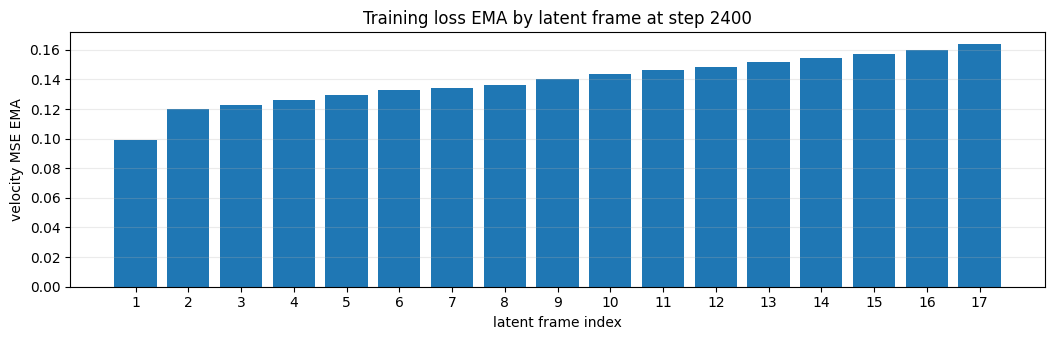

ssm-window:  12%|█▏        | 2400/20000 [35:41<30:44:38,  6.29s/it, bank=400, latent_err=0.053634, noise_err=0.057569, replay=0.56, window_ema=0.139177]

step 2400: 58186e7f0d9c2bfd | left=long windowed rollout=36 latent frames | middle=ground truth truncated to 141 video frames (from 161) | right=absolute error | solver=unipc, guide=1, seed=923833857
long_pred_latents: min=-4.312, max=4.938, mean=-0.193, std=1.482 | long_pred_video: min=-1.000, max=1.000, mean=0.243, std=0.510


ssm-window:  13%|█▎        | 2699/20000 [39:50<3:58:53,  1.21it/s, bank=400, latent_err=0.051770, noise_err=0.035570, replay=0.59, window_ema=0.111837] 

step 2700: 95b351213835b079 | nu=6.42e-04, rho=0.786 | left=ssm causal window L=4, solver=unipc, guide=1 | middle=ground truth | right=absolute error
pred_latents: min=-4.312, max=4.562, mean=-0.188, std=1.459 | gt_latents: min=-4.176, max=4.918, mean=-0.180, std=1.457 | pred_video: min=-1.000, max=1.000, mean=0.240, std=0.521 | gt_video: min=-1.000, max=1.000, mean=0.243, std=0.522


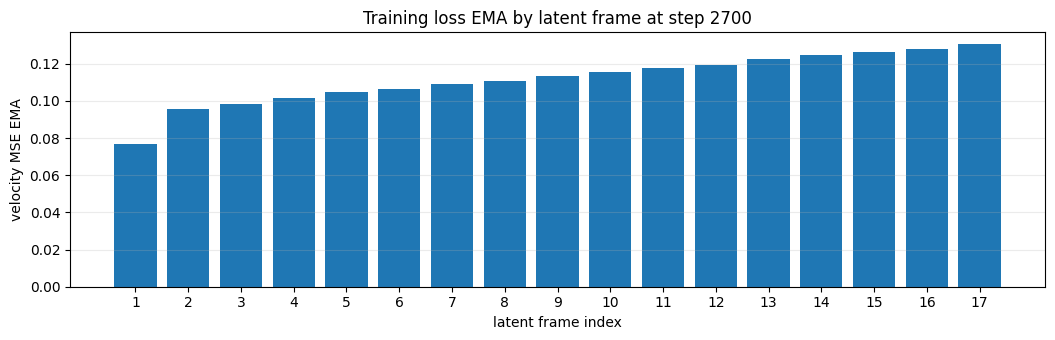

ssm-window:  14%|█▎        | 2700/20000 [40:08<30:13:16,  6.29s/it, bank=400, latent_err=0.051770, noise_err=0.035570, replay=0.59, window_ema=0.111837]

step 2700: 95b351213835b079 | left=long windowed rollout=36 latent frames | middle=ground truth truncated to 141 video frames (from 161) | right=absolute error | solver=unipc, guide=1, seed=190727096
long_pred_latents: min=-4.406, max=4.688, mean=-0.186, std=1.473 | long_pred_video: min=-1.000, max=1.000, mean=0.231, std=0.524


ssm-window:  14%|█▍        | 2849/20000 [42:12<4:14:06,  1.12it/s, bank=400, latent_err=0.048763, noise_err=0.061240, replay=0.49, window_ema=0.140230] 


KeyboardInterrupt: 

In [5]:
# Every EVAL_EVERY steps this samples one holdout latent, conditions on
# its first latent frame, and displays debug videos:
# first strip = prediction / ground truth / absolute error; second =
# double-length rollout / duration-matched ground truth / absolute error.
# Set TRAINING_MODE="ssm" above to use the separate LoRA + SSM student.
model, state = awl.train()
